In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [3]:
wine = load_wine()

X = wine.data
df = pd.DataFrame(X, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=1.5, min_samples=3)   
clusters = model.fit_predict(X_scaled)

df['cluster'] = clusters

In [13]:
print(df['cluster'].value_counts())

cluster
-1    147
 0      6
 1      5
 5      4
 6      4
 3      3
 4      3
 2      3
 7      3
Name: count, dtype: int64


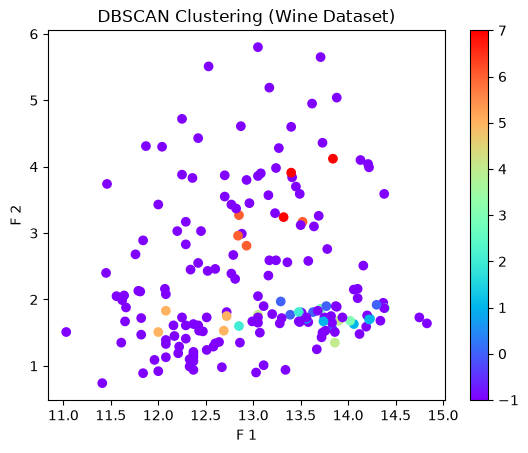

In [15]:
import matplotlib.pyplot as plt

plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['cluster'], cmap='rainbow')
plt.xlabel("F 1")
plt.ylabel("F 2")
plt.title("DBSCAN Clustering (Wine Dataset)")
plt.colorbar()
plt.show()

In [16]:
for i in sorted(df['cluster'].unique()):
    
    print("Cluster:", i)
    print(df[df['cluster'] == i].head(3))

Cluster: -1
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   

   od280/od315_of_diluted_wines  proline  cluster  
1                          3.40   1050.0       -1  
2                          3.17   1185.0       -1  
3                          3.45   1480.0       -1  
Cluster: 0
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
15    13.63        1.81  2.70               17.2      112.0      

In [17]:
df.groupby('cluster').mean()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
-1,12.905714,2.387619,2.350136,19.657823,99.231293,2.267891,1.983810,0.361020,1.580952,4.981633,0.955483,2.551701,718.292517
0,13.701667,1.823333,2.670000,17.866667,109.500000,2.908333,3.068333,0.345000,1.656667,6.200000,1.100000,2.848333,1260.000000
1,13.962000,1.684000,2.314000,16.100000,121.200000,2.950000,3.084000,0.266000,2.076000,5.930000,0.988000,3.504000,934.000000
2,13.276667,1.740000,2.513333,19.433333,97.000000,2.570000,2.653333,0.266667,1.660000,4.183333,1.083333,3.640000,926.666667
3,14.040000,1.803333,2.340000,15.733333,97.666667,2.586667,2.576667,0.276667,1.883333,4.583333,1.056667,3.723333,1120.000000
4,13.603333,1.600000,2.163333,16.333333,102.000000,3.026667,3.180000,0.236667,2.006667,6.120000,0.933333,3.410000,971.666667
5,12.372500,1.655000,2.320000,20.925000,82.750000,1.452500,1.492500,0.520000,1.630000,3.087500,0.992500,2.350000,478.250000
6,13.035000,3.052500,2.652500,22.625000,100.000000,1.765000,0.555000,0.540000,0.767500,4.862500,0.855000,2.157500,570.000000
7,13.520000,3.756667,2.413333,21.333333,94.333333,1.843333,0.780000,0.453333,1.406667,8.243333,0.606667,1.606667,626.666667


In [18]:
noise = df[df['cluster'] == -1]
print("Number of noise points:", len(noise))

Number of noise points: 147


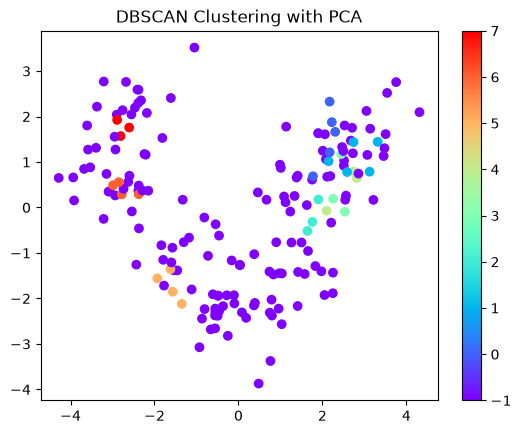

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='rainbow')
plt.title("DBSCAN Clustering with PCA")
plt.colorbar()
plt.show()

In [20]:
for eps in [0.5, 1.0, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=3)
    labels = model.fit_predict(X_scaled)
    print(f"eps={eps} → clusters:", set(labels))

eps=0.5 → clusters: {np.int64(-1)}
eps=1.0 → clusters: {np.int64(-1)}
eps=1.5 → clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(-1)}
eps=2.0 → clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(-1)}
